<a href="https://colab.research.google.com/github/sahibbedi/cftc-cot-tracker/blob/main/WeeklyCFTCChartUpdate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance -q

Fetching CFTC CoT Data...
COT DataFrame columns: Index(['id', 'market_and_exchange_names', 'report_date_as_yyyy_mm_dd',
       'yyyy_report_week_ww', 'contract_market_name',
       'cftc_contract_market_code', 'cftc_market_code', 'cftc_region_code',
       'cftc_commodity_code', 'commodity_name', 'open_interest_all',
       'dealer_positions_long_all', 'dealer_positions_short_all',
       'dealer_positions_spread_all', 'asset_mgr_positions_long',
       'asset_mgr_positions_short', 'asset_mgr_positions_spread',
       'lev_money_positions_long', 'lev_money_positions_short',
       'lev_money_positions_spread', 'other_rept_positions_long',
       'other_rept_positions_short', 'other_rept_positions_spread',
       'tot_rept_positions_long_all', 'tot_rept_positions_short',
       'nonrept_positions_long_all', 'nonrept_positions_short_all',
       'change_in_open_interest_all', 'change_in_dealer_long_all',
       'change_in_dealer_short_all', 'change_in_dealer_spread_all',
       'change_i

/tmp/ipykernel_8655/334867707.py:53: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download("BTC-USD BTC=F", start=start_date, progress=False)['Close'].dropna()


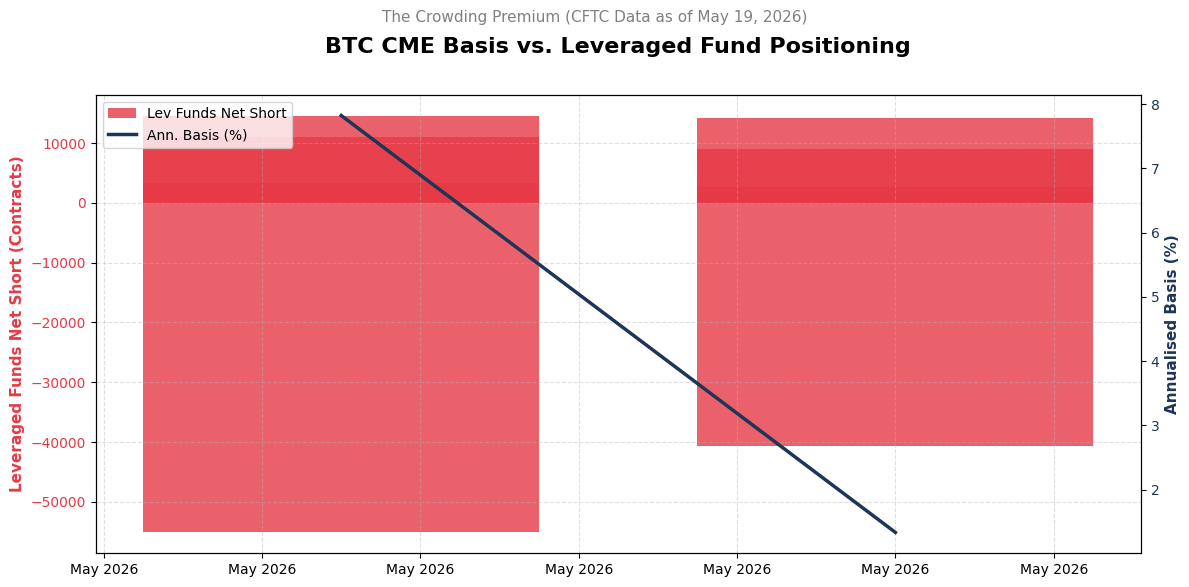

In [17]:
import requests
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def build_cot_chart():
    # 1. Fetch CFTC Data (Updated Endpoint)
    url = "https://publicreporting.cftc.gov/resource/gpe5-46if.json"
    params = {
        "$order": "report_date_as_yyyy_mm_dd DESC",
        "$limit": 156
    }

    print("Fetching CFTC CoT Data...")
    response = requests.get(url, params=params)
    response.raise_for_status()
    cot_df = pd.DataFrame(response.json())

    # Debugging: Print columns and unique market names to identify the correct Bitcoin market name
    print("COT DataFrame columns:", cot_df.columns)
    print("COT DataFrame shape:", cot_df.shape)
    if not cot_df.empty:
        if 'contract_market_name' in cot_df.columns:
            print("Unique contract_market_name values (first 10):", cot_df['contract_market_name'].unique()[:10]) # Limiting output
        if 'commodity_name' in cot_df.columns:
            print("Unique commodity_name values (first 10):", cot_df['commodity_name'].unique()[:10]) # Limiting output
    print("COT DataFrame head:\n", cot_df.head())

    # Filter for Bitcoin data
    bitcoin_cot_df = cot_df[
        (cot_df['contract_market_name'].str.contains('BITCOIN', case=False, na=False)) |
        (cot_df['commodity_name'].str.contains('BITCOIN', case=False, na=False))
    ].copy()

    if bitcoin_cot_df.empty:
        print("No Bitcoin data found with current filters.")
        return # Exit if no Bitcoin data

    print("Filtered Bitcoin COT DataFrame head:\n", bitcoin_cot_df.head())

    # Process Leveraged Funds Net Short
    cot_df = bitcoin_cot_df.copy() # Use the filtered DataFrame for further processing
    cot_df['Date'] = pd.to_datetime(cot_df['report_date_as_yyyy_mm_dd'])
    cot_df['Lev_Short'] = pd.to_numeric(cot_df['lev_money_positions_short'])
    cot_df['Lev_Long'] = pd.to_numeric(cot_df['lev_money_positions_long'])
    cot_df['Net_Short'] = cot_df['Lev_Short'] - cot_df['Lev_Long']
    cot_df = cot_df[['Date', 'Net_Short']].sort_values('Date').set_index('Date')

    # 2. Fetch Pricing Data for Basis
    print("Fetching pricing data for basis overlay...")
    start_date = cot_df.index.min().strftime('%Y-%m-%d')
    price_data = yf.download("BTC-USD BTC=F", start=start_date, progress=False)['Close'].dropna()
    price_data['Ann_Basis_Pct'] = ((price_data['BTC=F'] / price_data['BTC-USD']) - 1) * (365 / 30) * 100

    # 3. Merge Datasets
    merged = cot_df.join(price_data['Ann_Basis_Pct'], how='left').ffill()

    # 4. Generate the Chart
    print("Generating chart...")
    fig, ax1 = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#ffffff')

    # Net Short Bar Chart
    color1 = '#E63946'
    ax1.bar(merged.index, merged['Net_Short'], width=5, color=color1, alpha=0.8, label='Lev Funds Net Short')
    ax1.set_ylabel('Leveraged Funds Net Short (Contracts)', color=color1, fontweight='bold', fontsize=11)
    ax1.tick_params(axis='y', labelcolor=color1)

    latest_date = merged.index.max().strftime('%b %d, %Y')
    plt.title('BTC CME Basis vs. Leveraged Fund Positioning', fontsize=16, fontweight='bold', pad=30) # Increased pad
    plt.suptitle(f"The Crowding Premium (CFTC Data as of {latest_date})", fontsize=11, color='gray', y=0.97) # Increased y

    # Ann Basis Line Chart
    ax2 = ax1.twinx()
    color2 = '#1D3557'
    ax2.plot(merged.index, merged['Ann_Basis_Pct'], color=color2, linewidth=2.5, label='Ann. Basis (%)')
    ax2.set_ylabel('Annualised Basis (%)', color=color2, fontweight='bold', fontsize=11)
    ax2.tick_params(axis='y', labelcolor=color2)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.grid(True, linestyle='--', alpha=0.4)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

    fig.tight_layout()

    # Renders inline in Colab instead of saving to a file
    plt.show()

# Execute the function
build_cot_chart()